In [3]:
# Load the dataset
import pandas as pd
df = pd.read_csv("dataset/water_potability.csv")

In [4]:
# Display the number of records (rows)
print(f"Number of records (Rows): {df.shape[0]}")

Number of records (Rows): 3276


In [5]:
# Display the number of features (columns)
print(f"Number of features (Columns): {df.shape[1]}")

Number of features (Columns): 10


In [6]:
# Display target variable details
print("Target variable: 'Potability' (1 = Potable, 0 = Not Potable)\n")

Target variable: 'Potability' (1 = Potable, 0 = Not Potable)



In [7]:
# Check data types of features
print("--- Data Types ---")
print(df.dtypes)

--- Data Types ---
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


In [8]:
# Check for missing values in each feature
print("\n---Missing Values ---")
print(df.isnull().sum())


---Missing Values ---
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [9]:
# Check for duplicate records
print(f"\n---Duplicate Records ---")
print(f"Total duplicates: {df.duplicated().sum()}")


---Duplicate Records ---
Total duplicates: 0


In [10]:
# Generate descriptive statistical summary of features
print(df.describe())

                ph     Hardness        Solids  Chloramines      Sulfate  \
count  2785.000000  3276.000000   3276.000000  3276.000000  2495.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.594320    32.879761   8768.570828     1.583085    41.416840   
min       0.000000    47.432000    320.942611     0.352000   129.000000   
25%       6.093092   176.850538  15666.690297     6.127421   307.699498   
50%       7.036752   196.967627  20927.833607     7.130299   333.073546   
75%       8.062066   216.667456  27332.762127     8.114887   359.950170   
max      14.000000   323.124000  61227.196008    13.127000   481.030642   

       Conductivity  Organic_carbon  Trihalomethanes    Turbidity   Potability  
count   3276.000000     3276.000000      3114.000000  3276.000000  3276.000000  
mean     426.205111       14.284970        66.396293     3.966786     0.390110  
std       80.824064        3.308162        16.175008     0.780382     0.487849  


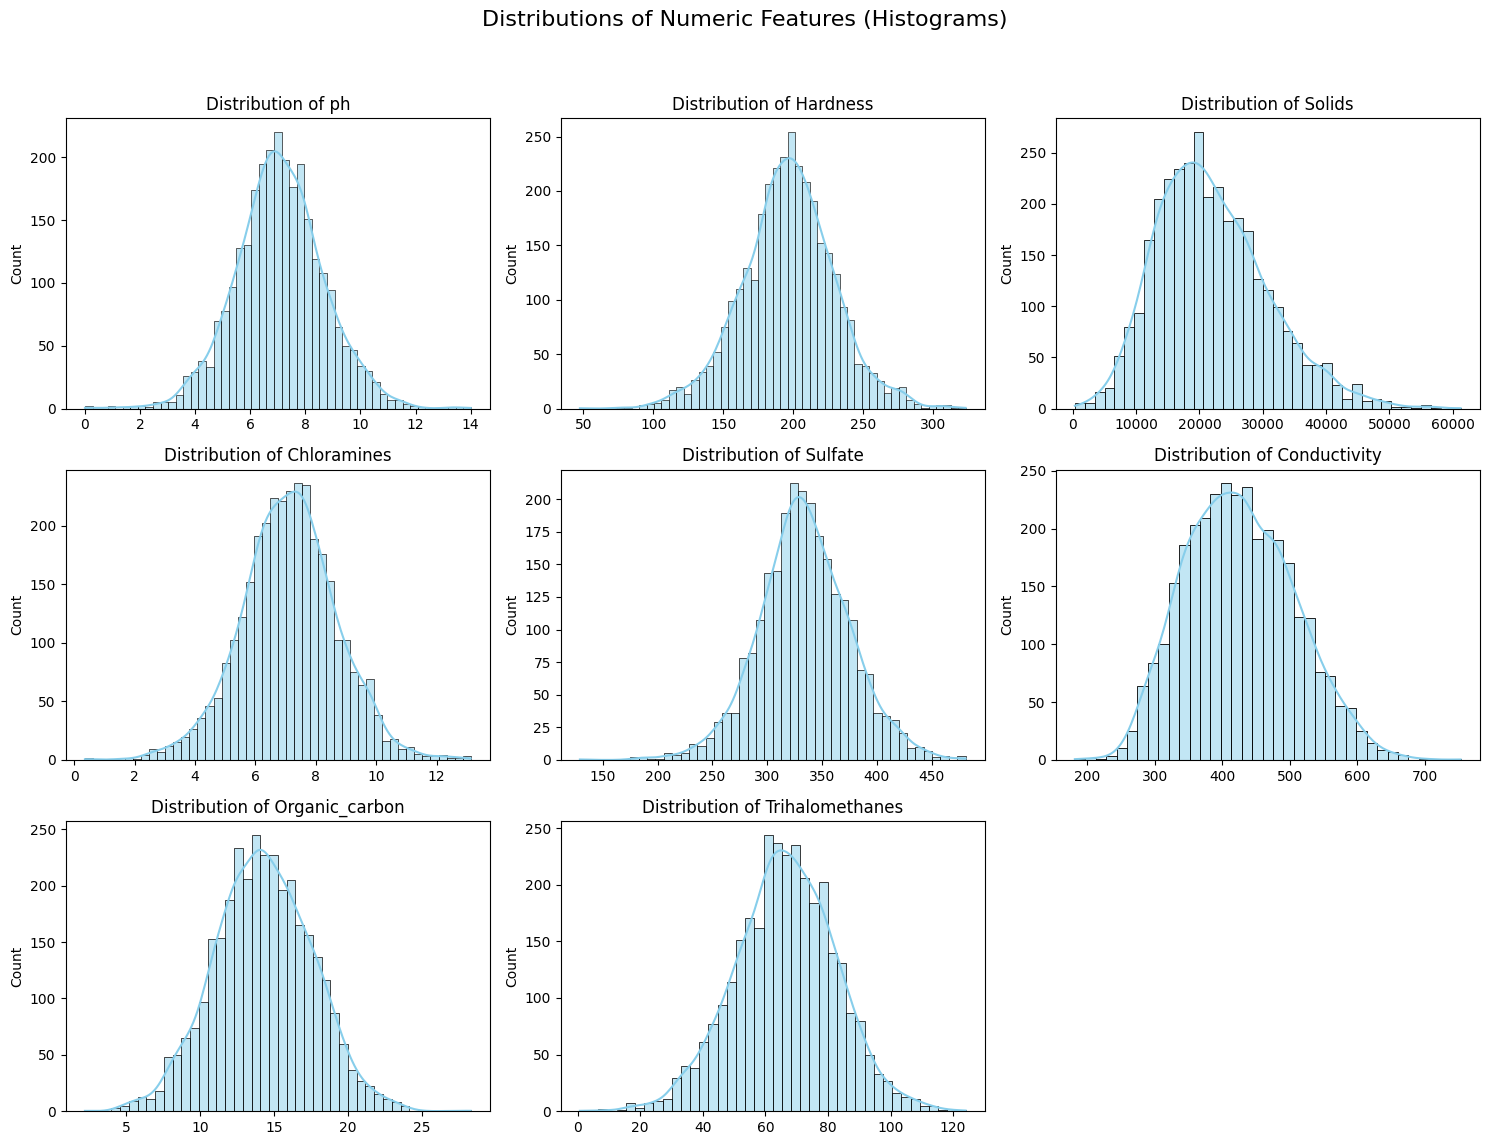

In [11]:
# Plot histograms to visualize numeric feature distributions
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df.drop('Potability', axis=1).columns

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle('Distributions of Numeric Features (Histograms)', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

fig.delaxes(axes[-1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

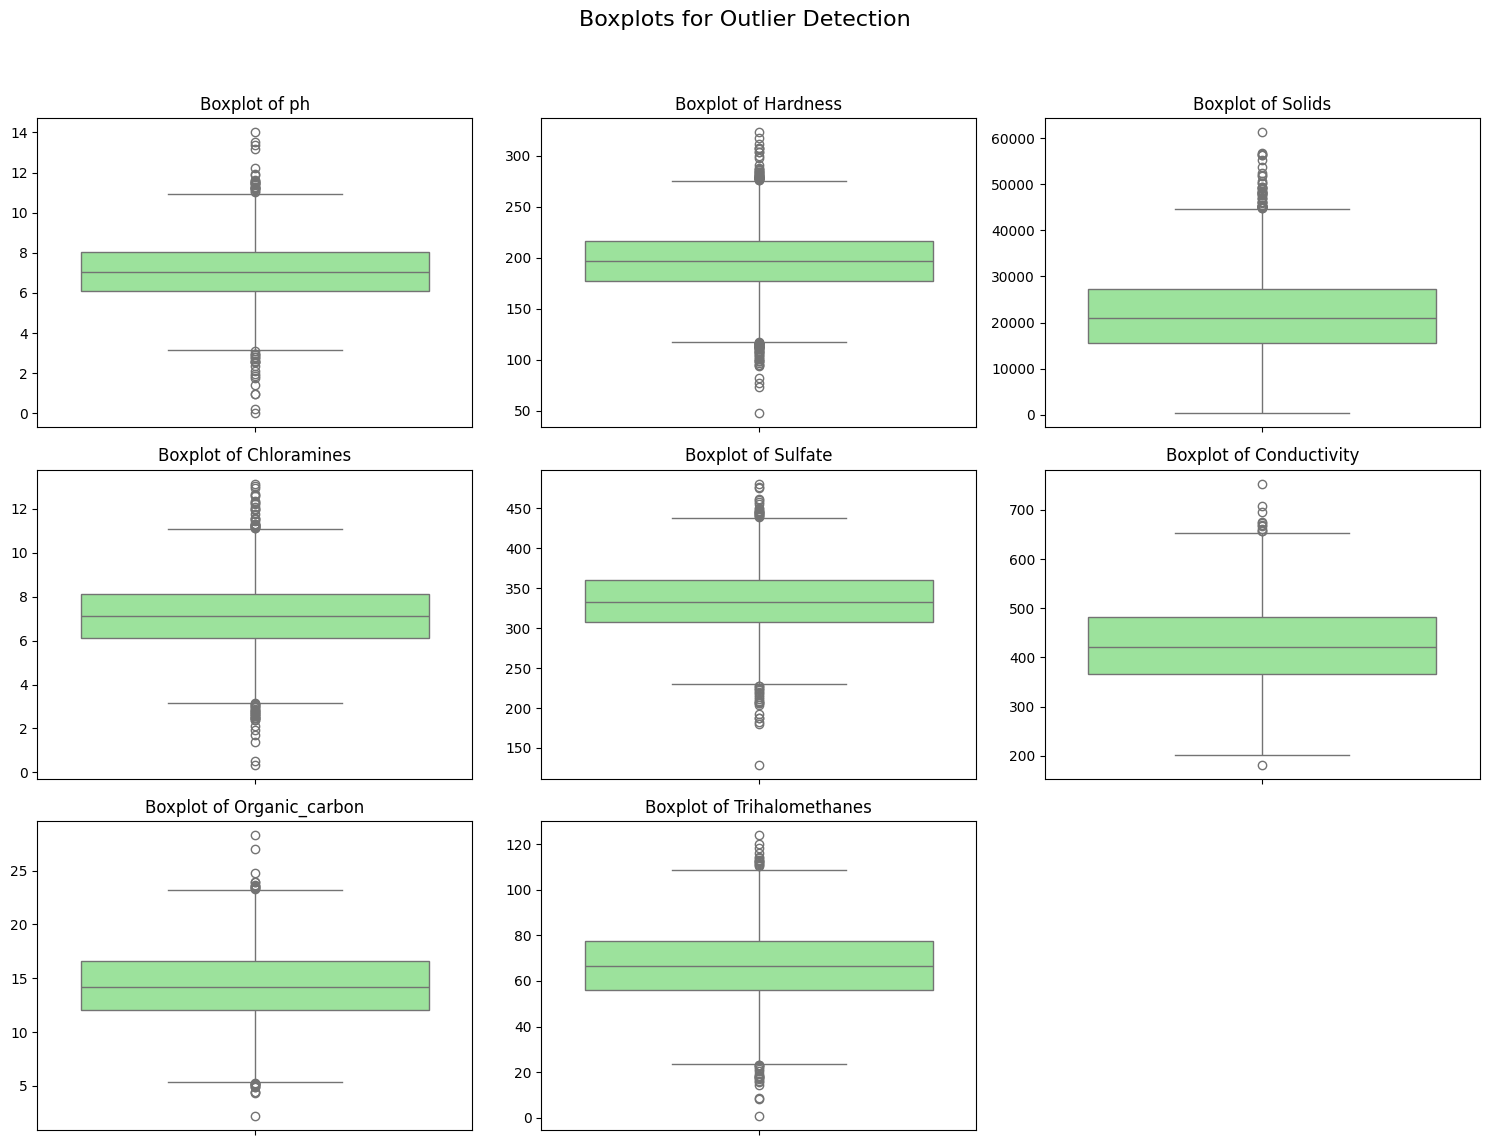

In [12]:
# Plot boxplots for outlier detection across features
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle('Boxplots for Outlier Detection', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

fig.delaxes(axes[-1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

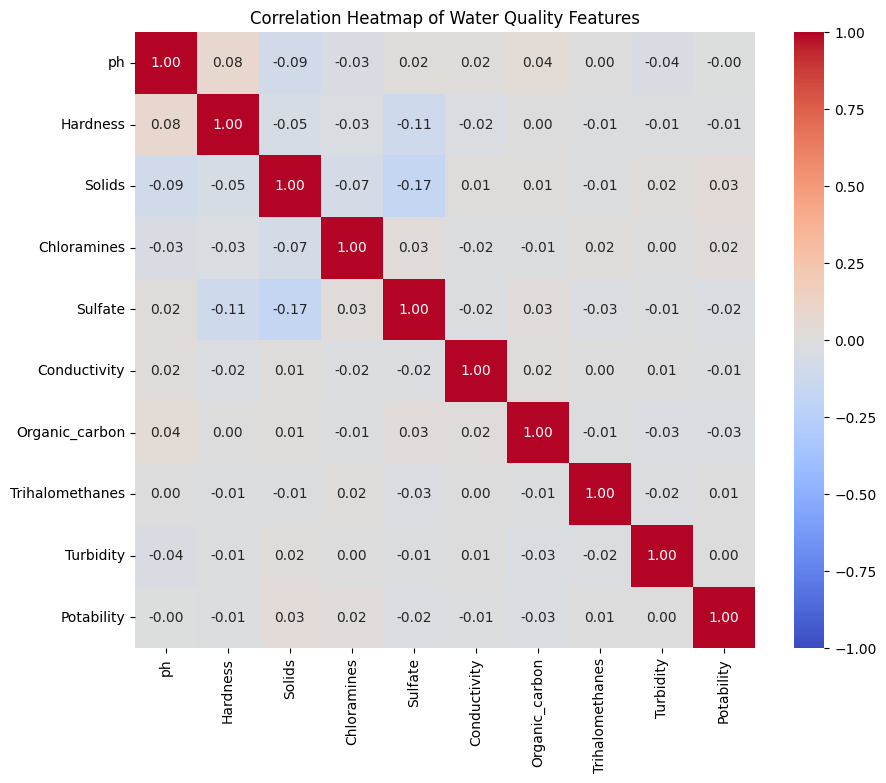

In [13]:
# Generate correlation heatmap of water quality features
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Water Quality Features')
plt.show()

In [14]:
# Check and remove duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total duplicate records found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New dataset shape: {df.shape}")
else:
    print("No duplicate records to remove.")


Total duplicate records found: 0
No duplicate records to remove.


In [15]:
# Check feature data types and concise info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [16]:
## Separate features X and target Y

X = df.drop("Potability", axis=1)
y = df["Potability"] 

In [44]:
import sys
sys.path.insert(0, r"C:\Users\Dilshan Hesara\Downloads\ML-FINAL-P\ML-Final-Project\venv\Lib\site-packages")

In [17]:
## split the dataset

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [18]:
# Handle missing values using training-set medians

missing_columns = ['ph', 'Sulfate', 'Trihalomethanes']

median_values = {}

for column in missing_columns:

    median_value = X_train[column].median()

    # Save the training median
    median_values[column] = median_value

    X_train[column] = X_train[column].fillna(median_value)
    X_test[column] = X_test[column].fillna(median_value)

print("Missing values handled using training-set medians.")

Missing values handled using training-set medians.


In [19]:
# Save median values as pkl file

import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(
    median_values,
    "model/median_values.pkl"
)

print("Median values saved successfully!")
print(median_values)

Median values saved successfully!
{'ph': np.float64(7.035036795196814), 'Sulfate': np.float64(333.073545745888), 'Trihalomethanes': np.float64(66.56570894421057)}


In [20]:
# Detect and treat outliers using IQR method
# IQR limits are calculated only from the training data

columns_to_be_checked = ['Hardness','Solids','Sulfate',]

iqr_limits = {}

for column in columns_to_be_checked:
    
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    iqr_limits[column] = (lower_limit, upper_limit)
    
    X_train[column] = X_train[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )
    
    X_test[column] = X_test[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print("Outlier treatment completed successfully.")

Outlier treatment completed successfully.


In [21]:
# Save the iqr limits as pkl file

joblib.dump(
    iqr_limits,
    "model/iqr_limits.pkl"
)

print("IQR limits saved successfully!")
print(iqr_limits)

IQR limits saved successfully!
{'Hardness': (np.float64(118.4279492765894), np.float64(275.22989913204435)), 'Solids': (np.float64(-1956.4180616652247), np.float64(44617.796410151044)), 'Sulfate': (np.float64(268.1456052874585), np.float64(399.15342983179))}


In [22]:
# log transformation


import numpy as np
import pandas as pd

column = 'Solids'

print("\nBefore Log Transformation:")
print(X_train[column].head(10))
print(f"\nMinimum value: {X_train[column].min():.2f}")
print(f"Maximum value: {X_train[column].max():.2f}")
print(f"Mean: {X_train[column].mean():.2f}")
print(f"Median: {X_train[column].median():.2f}")
print(f"Skewness: {X_train[column].skew():.4f}")

X_train[column] = np.log1p(X_train[column])
X_test[column] = np.log1p(X_test[column])

print("\nAfter Log Transformation:")
print(X_train[column].head(10))
print(f"\nMinimum value: {X_train[column].min():.4f}")
print(f"Maximum value: {X_train[column].max():.4f}")
print(f"Mean: {X_train[column].mean():.4f}")
print(f"Median: {X_train[column].median():.4f}")
print(f"Skewness: {X_train[column].skew():.4f}")

print("\nLog transformation completed successfully.")


Before Log Transformation:
2214    22308.821729
1634    12988.791229
2605    28966.569327
114     21871.838700
129     17087.076902
1813    19713.504368
1987    15525.393963
1047    14298.410462
2120    31044.738180
312     29299.123353
Name: Solids, dtype: float64

Minimum value: 320.94
Maximum value: 44617.80
Mean: 21829.54
Median: 20866.34
Skewness: 0.4756

After Log Transformation:
2214    10.012782
1634     9.471919
2605    10.273932
114      9.993001
129      9.746136
1813     9.889110
1987     9.650297
1047     9.567974
2120    10.343217
312     10.285347
Name: Solids, dtype: float64

Minimum value: 5.7744
Maximum value: 10.7059
Mean: 9.9032
Median: 9.9459
Skewness: -1.2910

Log transformation completed successfully.


In [23]:
#ph binning

bins = [-np.inf, 6.5, 7.5, np.inf]

labels = ['Acidic','Neutral','Alkaline']

X_train['ph_category'] = pd.cut(X_train['ph'],bins=bins,labels=labels)
X_test['ph_category'] = pd.cut(X_test['ph'],bins=bins,labels=labels)

print("\nTrain pH values with categories:")
print(X_train[['ph', 'ph_category']].head(10))

print("\nTest pH values with categories:")
print(X_test[['ph', 'ph_category']].head(10))

print("\nTrain category counts:")
print(X_train['ph_category'].value_counts(dropna=False))

print("\nTest category counts:")
print(X_test['ph_category'].value_counts(dropna=False))

print("\nBinning completed successfully.")



Train pH values with categories:
            ph ph_category
2214  7.822492    Alkaline
1634  6.037428      Acidic
2605  8.445219    Alkaline
114   6.745307     Neutral
129   6.506488     Neutral
1813  7.740454    Alkaline
1987  6.775631     Neutral
1047  6.883015     Neutral
2120  7.035037     Neutral
312   7.035037     Neutral

Test pH values with categories:
            ph ph_category
664   7.035037     Neutral
2530  6.172517      Acidic
2870  7.035037     Neutral
1045  6.369112      Acidic
95    6.140878      Acidic
1793  8.885626    Alkaline
202   8.369154    Alkaline
1766  7.984711    Alkaline
1960  8.128270    Alkaline
1558  8.473249    Alkaline

Train category counts:
ph_category
Neutral     1012
Alkaline     841
Acidic       767
Name: count, dtype: int64

Test category counts:
ph_category
Neutral     237
Alkaline    218
Acidic      201
Name: count, dtype: int64

Binning completed successfully.


In [24]:
#Encoding

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    categories=[labels],
    handle_unknown='ignore',
    sparse_output=False,
    dtype=int
)

train_encoded = encoder.fit_transform(X_train[['ph_category']])
test_encoded = encoder.transform(X_test[['ph_category']])

encoded_columns = ['ph_category_Acidic','ph_category_Neutral','ph_category_Alkaline']

train_encoded_df = pd.DataFrame(
    train_encoded,
    columns=encoded_columns,
    index=X_train.index
)

test_encoded_df = pd.DataFrame(
    test_encoded,
    columns=encoded_columns,
    index=X_test.index
)

X_train = pd.concat(
    [
        X_train,
        train_encoded_df
    ],
    axis=1
)

X_test = pd.concat(
    [
        X_test,
        test_encoded_df
    ],
    axis=1
)

X_train.drop(columns=['ph_category'],inplace=True)
X_test.drop(columns=['ph_category'],inplace=True)

print("\nFirst 10 encoded training records:")

print(
    X_train[
        [
            'ph',
            'ph_category_Acidic',
            'ph_category_Neutral',
            'ph_category_Alkaline'
        ]
    ].head(10)
)

print("\nFirst 10 encoded test records:")

print(
    X_test[
        [
            'ph',
            'ph_category_Acidic',
            'ph_category_Neutral',
            'ph_category_Alkaline'
        ]
    ].head(10)
)
print("\nEncoded column data types:")
print(X_train[encoded_columns].dtypes)
print("\nEncoding completed successfully.")


First 10 encoded training records:
            ph  ph_category_Acidic  ph_category_Neutral  ph_category_Alkaline
2214  7.822492                   0                    0                     1
1634  6.037428                   1                    0                     0
2605  8.445219                   0                    0                     1
114   6.745307                   0                    1                     0
129   6.506488                   0                    1                     0
1813  7.740454                   0                    0                     1
1987  6.775631                   0                    1                     0
1047  6.883015                   0                    1                     0
2120  7.035037                   0                    1                     0
312   7.035037                   0                    1                     0

First 10 encoded test records:
            ph  ph_category_Acidic  ph_category_Neutral  ph_category_Alkal

In [25]:
# Save the encoder values as pkl file


joblib.dump(
    encoder,
    "model/encoder.pkl"
)
print("Encode Values saved successfully!")
print(encoder)

Encode Values saved successfully!
OneHotEncoder(categories=[['Acidic', 'Neutral', 'Alkaline']],
              dtype=<class 'int'>, handle_unknown='ignore',
              sparse_output=False)


In [26]:
## Standardization the x_train and x_test

from sklearn.preprocessing import StandardScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
## Define the model algorithms

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {

    "Random Forest": RandomForestClassifier(n_estimators=200,random_state=42,class_weight="balanced"),

    "XGBoost": XGBClassifier(n_estimators=200,learning_rate=0.05,max_depth=5,random_state=42,eval_metric="logloss"),

    "SVM": SVC(kernel="rbf",probability=True,random_state=42)
}

In [28]:
##  Train each machine learning model using the scaled training data

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)


    print(f"{name} successfully trained!")
    print("-" * 40)

Training Random Forest...
Random Forest successfully trained!
----------------------------------------
Training XGBoost...
XGBoost successfully trained!
----------------------------------------
Training SVM...


c:\Users\Dell\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVM successfully trained!
----------------------------------------


In [30]:
# Evaluate all trained models and evaluate their performance using classification metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

results = []
trained_models = {}

for model_name, model in models.items():

    print(f"\nEvaluating {model_name}...")

    y_pred = model.predict(X_test_scaled)

    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "ROC-AUC": roc_auc
    })

    trained_models[model_name] = model


Evaluating Random Forest...
Accuracy  : 0.6646
Precision : 0.5938
Recall    : 0.4453
F1-Score  : 0.5089
ROC-AUC   : 0.6658

Confusion Matrix:
[[322  78]
 [142 114]]

Evaluating XGBoost...
Accuracy  : 0.6631
Precision : 0.6296
Recall    : 0.3320
F1-Score  : 0.4348
ROC-AUC   : 0.6409

Confusion Matrix:
[[350  50]
 [171  85]]

Evaluating SVM...
Accuracy  : 0.6631
Precision : 0.6606
Recall    : 0.2812
F1-Score  : 0.3945
ROC-AUC   : 0.6358

Confusion Matrix:
[[363  37]
 [184  72]]


In [31]:
## compare the models performances

results_df = pd.DataFrame(results)

print("\nMODEL COMPARISON")
print("=" * 70)

print(
    results_df.sort_values(
        by="F1-Score",
        ascending=False
    ).to_string(index=False)
)


MODEL COMPARISON
        Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Random Forest  0.664634    0.59375 0.445312  0.508929 0.665786
      XGBoost  0.663110    0.62963 0.332031  0.434783 0.640889
          SVM  0.663110    0.66055 0.281250  0.394521 0.635791


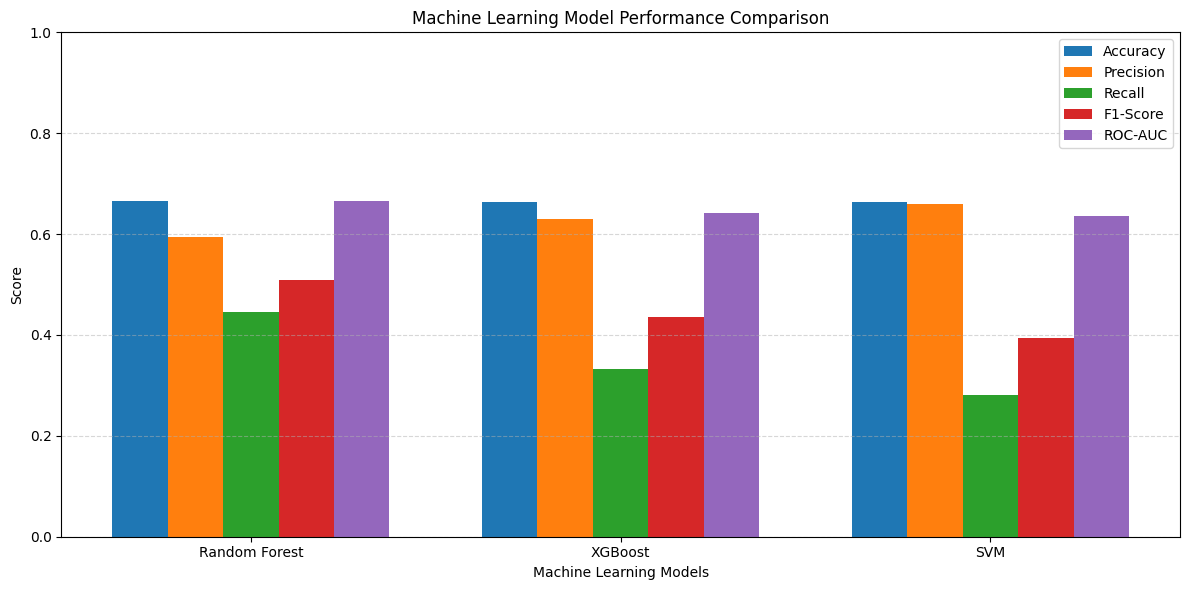

In [ ]:
# Plot model performance comparison

import matplotlib.pyplot as plt
import numpy as np

metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

x = np.arange(len(results_df["Model"]))
width = 0.15

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        results_df[metric],
        width,
        label=metric
    )

plt.xlabel("Machine Learning Models")
plt.ylabel("Score")
plt.title("Machine Learning Model Performance Comparison")

plt.xticks(x + width * 2,results_df["Model"])

plt.ylim(0, 1.0)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [33]:
## select the best model

best_model_name = results_df.loc[
    results_df["F1-Score"].idxmax(),
    "Model"
]

best_model = trained_models[best_model_name]

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print("Best Model:", best_model_name)


BEST MODEL
Best Model: Random Forest


In [36]:
# Save the trained model and preprocessing objects

import joblib
import os

os.makedirs("model", exist_ok=True)

joblib.dump(
    best_model,
    "model/water_potability_model.pkl"
)

joblib.dump(
    scaler,
    "model/scaler.pkl"
)

joblib.dump(
    X_train.columns.tolist(),
    "model/feature_columns.pkl"
)

print("Model files saved successfully!")
print()
print("1. water_potability_model.pkl")
print("2. scaler.pkl")
print("3. feature_columns.pkl")

Model files saved successfully!

1. water_potability_model.pkl
2. scaler.pkl
3. feature_columns.pkl
